<a href="https://colab.research.google.com/github/Ayushjha02/speech-to-text/blob/main/audio_token.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Mouting google drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Importing essential Module**

In [ ]:
import pandas as pd
import glob
import IPython.display as ipd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
!pip install --upgrade --force-reinstall librosa

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.7/260.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 427.6/427.6 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.4/240.4 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/4

In [ ]:
import librosa
import librosa.display


**Reading metadata cointaining filename and text associated with it**

In [ ]:
audio_file_metadata = pd.read_csv("/content/drive/MyDrive/metadata.csv")

In [ ]:
audio_file_metadata.head()

,Unnamed: 0,id,sentence,file_name,audio_path
0,0,LJ001-0001,"Printing, in the only sense with which we are ...",LJ001-0001.wav,/kaggle/input/ljspeech-dataset/LJSpeech-1.1/wa...
1,1,LJ001-0002,in being comparatively modern.,LJ001-0002.wav,/kaggle/input/ljspeech-dataset/LJSpeech-1.1/wa...
2,2,LJ001-0003,For although the Chinese took impressions from...,LJ001-0003.wav,/kaggle/input/ljspeech-dataset/LJSpeech-1.1/wa...
3,3,LJ001-0004,"produced the block books, which were the immed...",LJ001-0004.wav,/kaggle/input/ljspeech-dataset/LJSpeech-1.1/wa...
4,4,LJ001-0005,the invention of movable metal letters in the ...,LJ001-0005.wav,/kaggle/input/ljspeech-dataset/LJSpeech-1.1/wa...


In [ ]:
df = audio_file_metadata[['file_name','sentence']]
df = df.rename(columns={
    "file_name": "audio",
    "sentence": "text"
})



In [ ]:
df.head()

,audio,text
0,LJ001-0001.wav,"Printing, in the only sense with which we are ..."
1,LJ001-0002.wav,in being comparatively modern.
2,LJ001-0003.wav,For although the Chinese took impressions from...
3,LJ001-0004.wav,"produced the block books, which were the immed..."
4,LJ001-0005.wav,the invention of movable metal letters in the ...


**List out all the audio**

In [ ]:
glob_list = glob.glob("/content/drive/MyDrive/wavs (1)/*.wav")


In [ ]:
#play audio
ipd.Audio(glob_list[0])

In [ ]:
y ,sr= librosa.load(glob_list[0])
y,sr

(array([-5.8886071e-05, -9.9764118e-05, -5.1716685e-05, ...,
         7.9115020e-04, -4.8122190e-05,  0.0000000e+00],
       shape=(76703,), dtype=float32),
 22050)

**Visualising audio files**

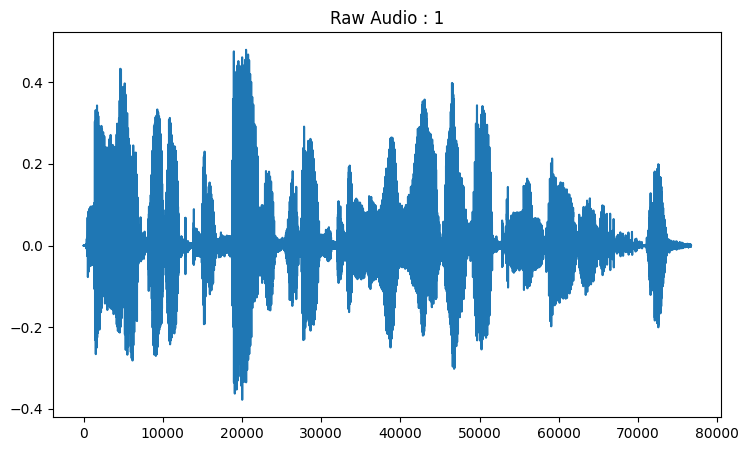

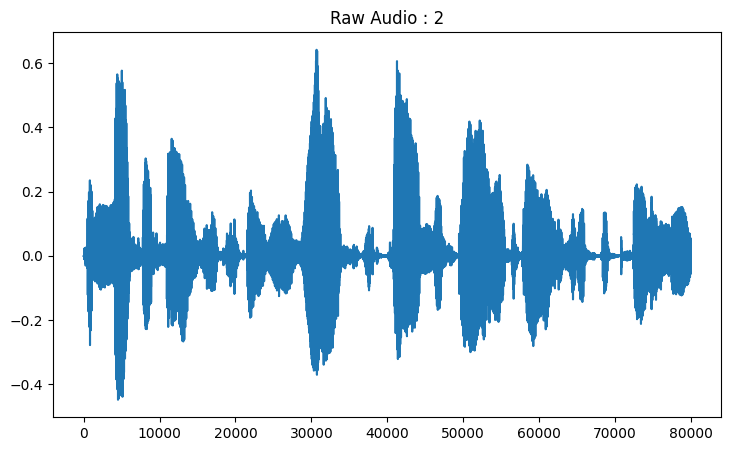

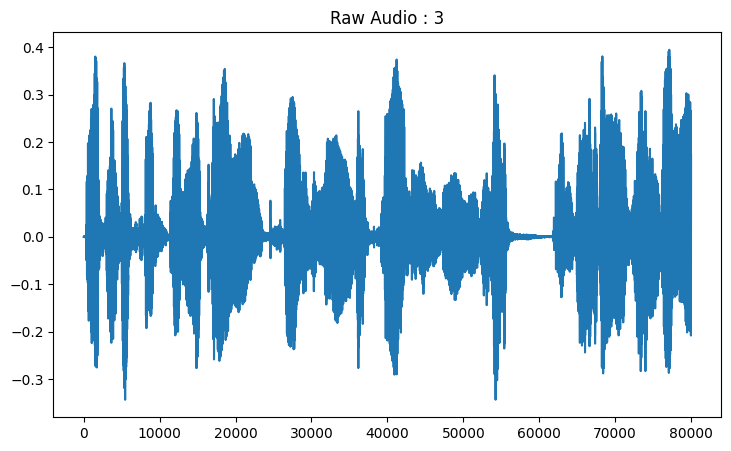

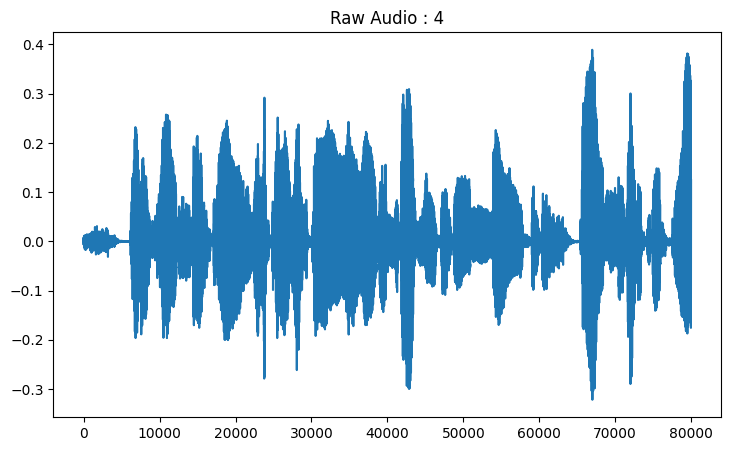

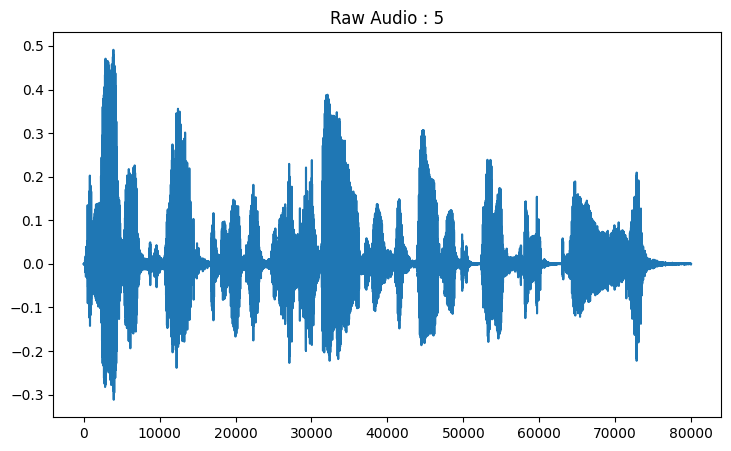

In [ ]:
for i in range(5):

  y,sr = librosa.load(glob_list[i])
  plt.subplot(1,5,i+1)
  pd.Series(y[0:80000]).plot(figsize=(50,5),
                  title=f"Raw Audio : {i+1}" )
  plt.show()

**spectrogram visualisation**

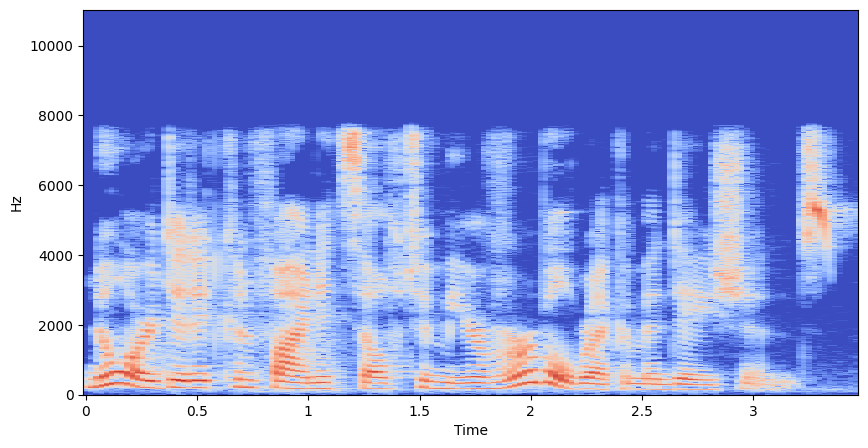

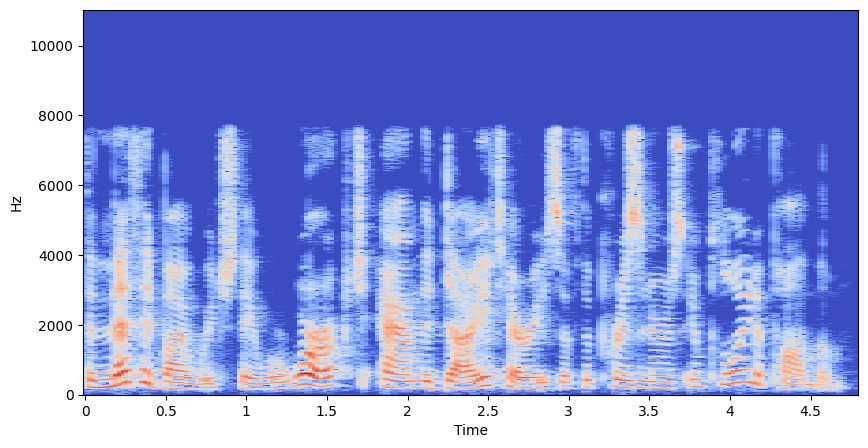

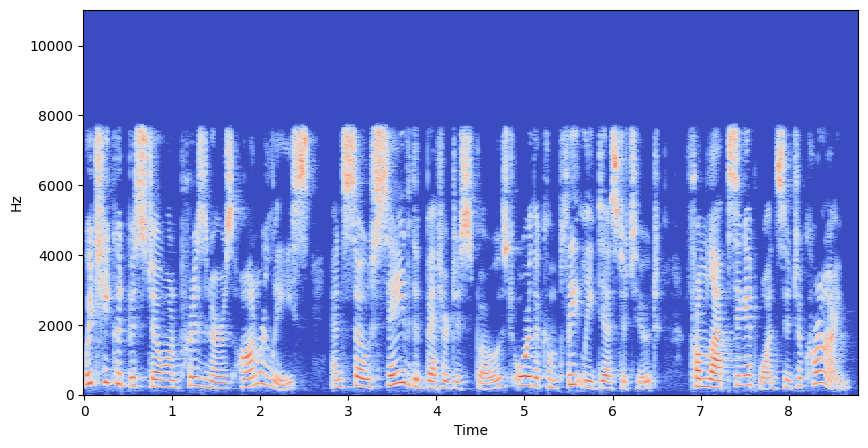

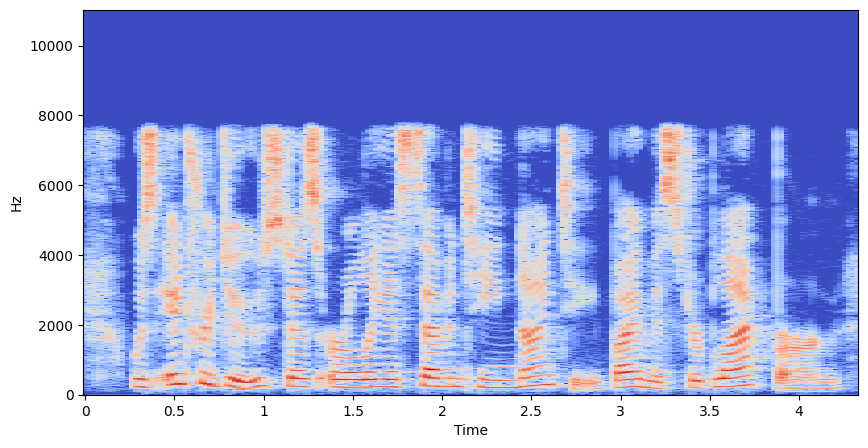

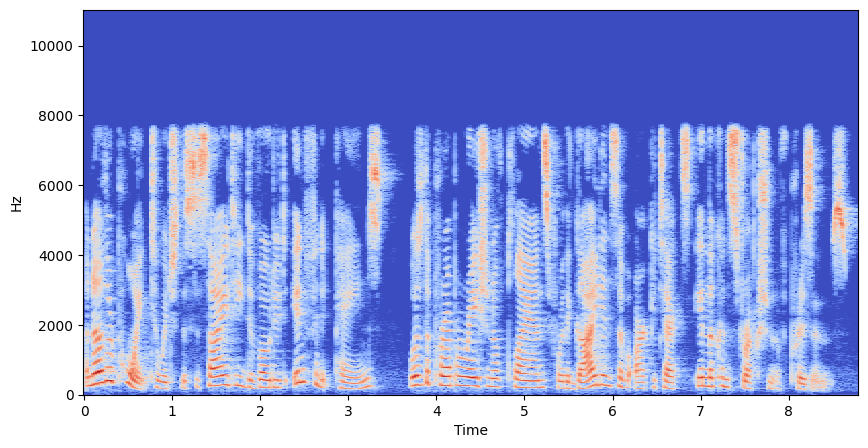

In [ ]:
for i in range(5):
  y,sr = librosa.load(glob_list[i])
  s = librosa.stft(y)
  s_db = librosa.amplitude_to_db(abs(s))

  fig,ax = plt.subplots(figsize=(10,5))
  img = librosa.display.specshow(s_db,
                                sr=sr,ax=ax,
                                x_axis='time',
                             y_axis='hz')

  plt.show()



In [ ]:
import os
for value in df['audio']:
 audio_path = '/content/drive/MyDrive/wavs (1)/' + value
 if os.path.exists(audio_path):
  continue
 else:
  df.drop(df[df['audio'] == value].index, inplace = True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2160 entries, 0 to 2159
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   audio   2160 non-null   object
 1   text    2160 non-null   object
dtypes: object(2)
memory usage: 50.6+ KB


**text processing using tokeniser**

In [42]:
from transformers import GPT2Tokenizer

In [46]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")


#example how text tokenisation work

In [47]:
index = tokenizer.encode('hello how are you?')

In [48]:
index

[31373, 703, 389, 345, 30]

In [49]:
for value in df['audio']:
 audio_path = '/content/drive/MyDrive/wavs (1)/' + value
 y,sr = librosa.load(audio_path)
 index = tokenizer.encode(df[df['audio'] == value]['text'].values[0])

In [64]:
for i in df['audio']


/content/drive/MyDrive/wavs (1)/LJ001-0138.wav
LJ008-0167.wav


create mel and index pair for dataset

In [67]:
def create_mel_index_pair(df):
  for value in df['audio']:
   audio_path = '/content/drive/MyDrive/wavs (1)/' + value
   y,sr = librosa.load(audio_path)
   mel = librosa.feature.melspectrogram(y=y)
   index = tokenizer.encode(df[df['audio'] == value]['text'].values[0])
   return mel,index


In [68]:
mel_index_pair = create_mel_index_pair(df)